# Quantum Portfolio Optimization
Based on Kerenidis et al. (Quantum Algorithms for Portfolio Optimization)

## 1. Setup and Data Ingestion

Run this once in a clean environment:

```bash
pip install qiskit qiskit-aer qiskit-optimization yfinance pandas numpy scipy matplotlib seaborn pylatexenc
```

In [114]:
# Run this once in a clean environment:
# !pip install qiskit qiskit-aer qiskit-optimization pylatexenc yfinance pandas numpy scipy matplotlib seaborn

In [115]:
import importlib
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.linalg
from scipy.optimize import minimize

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
# Modern imports from the unified library to avoid DeprecationWarnings
from qiskit.circuit.library import PhaseEstimation

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid")

print("Core package versions:")
for pkg in ["numpy", "pandas", "scipy", "yfinance", "qiskit", "qiskit_aer", "matplotlib", "seaborn", "pylatexenc"]:
    try:
        print(f"- {pkg}: {importlib.import_module(pkg).__version__}")
    except Exception as exc:
        print(f"- {pkg}: not found ({exc})")

Core package versions:
- numpy: 1.26.4
- pandas: 2.2.3
- scipy: 1.13.1
- yfinance: 0.2.58
- qiskit: 1.4.2
- qiskit_aer: 0.15.1
- matplotlib: 3.8.4
- seaborn: 0.13.2
- pylatexenc: 2.10


## 2. Classical Optimization Baseline

The objective is to minimize the portfolio variance $w^T \Sigma w$ subject to linear constraints.

### Configuration

In [116]:
CONFIG = {
    # Data controls
    # "tickers": ["AAPL", "MSFT", "NVDA", "AMZN"],
    "tickers": ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA"], # Uncomment for full run

    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "trading_days_per_year": 252,

    # Constraint controls
    "total_allocation": 1.0,          # budget: sum(w)=1.0
    "max_weight": 0.30,               # diversification cap
    "default_min_weight": 0.0,        # long-only lower bound
    "target_return": 0.20,            # annualized expected return target

    # Optional additional bounds per asset
    # Example: {"AAPL": (0.05, 0.20)} forces AAPL to be between 5% and 20%
    "custom_bounds": {},

    # Example: [({"AAPL": 1.0, "MSFT": 1.0}, 0.40)] forces AAPL + MSFT <= 40%
    "extra_inequalities": [],

    # Numerical controls
    "eps_cov_regularization": 1e-8,
    "optimizer_ftol": 1e-9,
    "optimizer_maxiter": 2000,

    # Sensitivity grid
    "sweep_target_returns": [0.12, 0.16, 0.20, 0.24],
    "sweep_max_weights": [0.20, 0.25, 0.30, 0.35],

    # Advanced Quantum Solver Controls
    "quantum_ipm_alpha": 0.5,         # Step size for IPM loop (0.1 = slow/safe, 0.9 = fast/risky)
    "quantum_hhl_n_clk": 6,           # Clock qubits for Phase Estimation precision
    "quantum_hhl_pad_eig": 0.1,       # Matrix padding eigenvalue to avoid div-by-zero in HHL
}

print(f"CONFIG loaded with {len(CONFIG['tickers'])} assets.")


CONFIG loaded with 7 assets.


### Advanced Quantum Tunable Parameters Note
- **`quantum_ipm_alpha`**: Controls how aggressively the Interior Point Method steps toward the solution. A higher value converges faster but risks stepping out of bounds.
- **`quantum_hhl_n_clk`**: Determines the precision of the simulated quantum Newton step. Higher clock qubits = sharper precision, but exponential increase in circuit depth.
- **`quantum_hhl_pad_eig`**: Padding constant applied to the unitary matrix to ensure eigenvalues don't drop to 0.


### How Tunables Affect Results

- `target_return`: higher target usually increases risk and can cause infeasibility.
- `max_weight`: lower cap enforces diversification but may reduce achievable return.
- `extra_inequalities`: add business constraints; each may tighten feasible region.
- `eps_cov_regularization`: stabilizes optimization if covariance is near-singular.
- `optimizer_ftol` / `optimizer_maxiter`: accuracy/runtime trade-off in classical solve.
- `quantum_shots` / `quantum_seed`: sampling noise and reproducibility in simulator demo.
- `ansatz_reps`: deeper circuits can represent richer states but increase cost/noise sensitivity.

### Data Ingestion from yfinance

In [117]:
tickers = CONFIG["tickers"]
raw = yf.download(
    tickers=tickers,
    start=CONFIG["start_date"],
    end=CONFIG["end_date"],
    auto_adjust=True,  # Automatically adjusts Open/High/Low/Close for dividends/splits
    progress=False,     # Disables the verbose download progress bar
)

# yfinance returns a MultiIndex (Level 0: Price Type, Level 1: Ticker) for multiple tickers
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw.copy()

# Standardize cleaning: remove empty rows, forward-fill gaps, and drop assets with any missing data
prices = prices.dropna(how="all").ffill().dropna(axis=1, how="any")
# Ensure columns match our requested order
prices = prices[tickers] if set(tickers).issubset(prices.columns) else prices

returns_daily = prices.pct_change().dropna(how="any")

# Annualize returns and covariance based on trading days
annual_factor = CONFIG["trading_days_per_year"]
mu_annual = returns_daily.mean() * annual_factor
sigma_annual = returns_daily.cov() * annual_factor

# Regularize covariance: add a tiny value to diagonal for numerical stability (prevents singular matrix)
sigma_annual = sigma_annual + np.eye(len(sigma_annual)) * CONFIG["eps_cov_regularization"]

print(f"Price shape: {prices.shape}")
print(f"Return shape: {returns_daily.shape}")
print("Tickers used:", list(prices.columns))

display(mu_annual.to_frame("annual_expected_return"))

Price shape: (249, 7)
Return shape: (248, 7)
Tickers used: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'TSLA']


,annual_expected_return
Ticker,
AAPL,0.171660
MSFT,0.191473
NVDA,0.433640
AMZN,0.114339
META,0.182109
GOOGL,0.569783
TSLA,0.382714


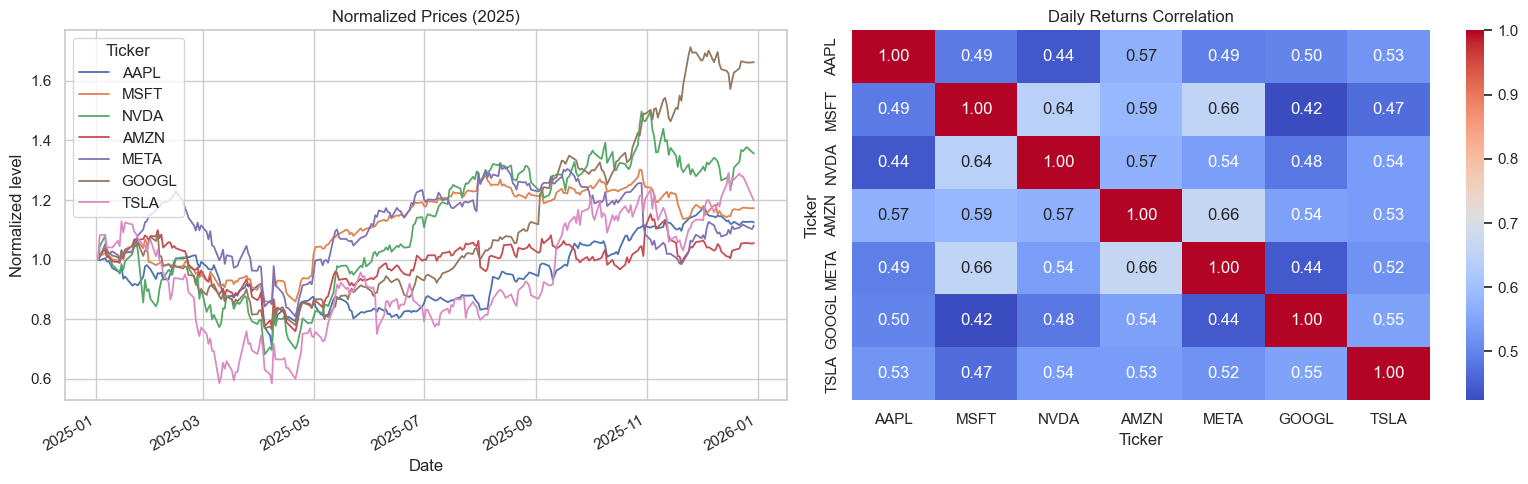

In [118]:
## Diagnostics plots

norm_prices = prices / prices.iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

norm_prices.plot(ax=axes[0], lw=1.3)
axes[0].set_title("Normalized Prices (2025)")
axes[0].set_ylabel("Normalized level")

sns.heatmap(returns_daily.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Daily Returns Correlation")

plt.tight_layout()
plt.show()

## 3. Baseline Constraint Validation

In [119]:
assets = list(prices.columns)
n = len(assets)
mu_vec = mu_annual.values # expected returns
cov = sigma_annual.values # cov matrix

min_default = CONFIG["default_min_weight"]
max_default = CONFIG["max_weight"]

bounds = []
for a in assets:
    if a in CONFIG["custom_bounds"]:
        bounds.append(CONFIG["custom_bounds"][a])
    else:
        bounds.append((min_default, max_default))

def portfolio_variance(w: np.ndarray, cov_mat: np.ndarray) -> float:
    return float(w @ cov_mat @ w)

def solve_constrained_portfolio(target_return: float, max_weight: float = None):
    bnds = []
    for i, a in enumerate(assets):
        lo, hi = bounds[i]
        if max_weight is not None:
            hi = min(hi, max_weight)
        bnds.append((lo, hi))

    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - CONFIG["total_allocation"]},
        {"type": "ineq", "fun": lambda w: float(w @ mu_vec - target_return)},
    ]

    # Extra inequalities Cw <= d converted to scipy form d - Cw >= 0
    for coeffs, rhs in CONFIG["extra_inequalities"]:
        row = np.array([coeffs.get(a, 0.0) for a in assets], dtype=float)
        cons.append({"type": "ineq", "fun": lambda w, row=row, rhs=rhs: float(rhs - row @ w)})

    x0 = np.repeat(CONFIG["total_allocation"] / n, n) # Initial guess = equal weight

    t0 = time.time()
    res = minimize(
        portfolio_variance,
        x0=x0,
        args=(cov,),
        method="SLSQP",
        bounds=bnds,
        constraints=cons,
        options={"maxiter": CONFIG["optimizer_maxiter"], "ftol": CONFIG["optimizer_ftol"], "disp": False},
    )
    elapsed = time.time() - t0

    return res, elapsed

baseline_res, baseline_time = solve_constrained_portfolio(CONFIG["target_return"], CONFIG["max_weight"])

if not baseline_res.success:
    print("Optimization failed:", baseline_res.message)
else:
    w_star = baseline_res.x
    ret_star = float(w_star @ mu_vec)
    var_star = float(w_star @ cov @ w_star)
    std_star = np.sqrt(var_star)

    print(f"Solved in {baseline_time:.4f}s")
    print(f"Expected annual return: {ret_star:.4f}")
    print(f"Annual variance: {var_star:.6f}")
    print(f"Annual volatility: {std_star:.4f}")

    display(pd.DataFrame({"asset": assets, "weight": w_star}).sort_values("weight", ascending=False))

Solved in 0.0085s
Expected annual return: 0.2924
Annual variance: 0.058332
Annual volatility: 0.2415


,asset,weight
1,MSFT,0.300000
5,GOOGL,0.300000
0,AAPL,0.276055
3,AMZN,0.087708
4,META,0.036237
2,NVDA,0.000000
6,TSLA,0.000000


In [120]:
## Baseline constraint validation table

def build_constraint_report(w: np.ndarray, target_return: float, max_weight: float) -> pd.DataFrame:
    rows = []
    rows.append(("budget_eq", float(np.sum(w) - CONFIG["total_allocation"]), "~0"))
    rows.append(("return_ineq (>=0)", float(w @ mu_vec - target_return), ">=0"))
    rows.append(("long_only_min", float(np.min(w)), ">=0"))
    rows.append(("max_weight_cap", float(max_weight - np.max(w)), ">=0"))

    for i, (coeffs, rhs) in enumerate(CONFIG["extra_inequalities"]):
        row = np.array([coeffs.get(a, 0.0) for a in assets], dtype=float)
        rows.append((f"extra_ineq_{i} (rhs-row@w)", float(rhs - row @ w), ">=0"))

    out = pd.DataFrame(rows, columns=["constraint", "value", "condition"])
    out["is_satisfied"] = out.apply(
        lambda r: abs(r["value"]) <= 1e-6 if r["condition"] == "~0" else r["value"] >= -1e-6,
        axis=1,
    )
    return out

if baseline_res.success:
    report = build_constraint_report(baseline_res.x, CONFIG["target_return"], CONFIG["max_weight"])
    display(report)
else:
    print("No report because baseline did not converge.")

,constraint,value,condition,is_satisfied
0,budget_eq,0.000000,~0,True
1,return_ineq (>=0),0.092392,>=0,True
2,long_only_min,0.000000,>=0,True
3,max_weight_cap,0.000000,>=0,True


## 4. Quantum-Ready Reformulations

In [121]:
## Construct M from Sigma and verify Sigma ~ M^T M

eigvals, eigvecs = np.linalg.eigh(cov)
eigvals_clipped = np.clip(eigvals, a_min=0.0, a_max=None)
M = np.diag(np.sqrt(eigvals_clipped)) @ eigvecs.T
reconstructed = M.T @ M

recon_error = np.linalg.norm(cov - reconstructed, ord="fro")
print(f"Frobenius reconstruction error ||Sigma - M^T M||_F: {recon_error:.6e}")

if baseline_res.success:
    w = baseline_res.x
    quad_val = float(w @ cov @ w)
    norm_val = float(np.linalg.norm(M @ w) ** 2)
    print(f"w^T Sigma w           = {quad_val:.8f}")
    print(f"||M w||_2^2           = {norm_val:.8f}")
    print(f"Absolute difference   = {abs(quad_val - norm_val):.3e}")

Frobenius reconstruction error ||Sigma - M^T M||_F: 3.775804e-16
w^T Sigma w           = 0.05833153
||M w||_2^2           = 0.05833153
Absolute difference   = 4.857e-17


## 5. Quantum Linear Algebra Subroutines
Implementation of the simulated Quantum Linear System Solver (HHL/Block-Encoding) for the Newton step.

In [122]:
def quantum_newton_solver(K_mat, r_vec, n_clk=CONFIG.get("quantum_hhl_n_clk", 6)):
    """
    Solves K|dz> = |r> using a fully custom HHL circuit implemented in Qiskit.
    """
    from qiskit import QuantumRegister, QuantumCircuit
    from qiskit.circuit.library import QFT, RYGate
    from qiskit.quantum_info import Operator, Statevector
    import scipy.linalg
    import numpy as np
    
    K_herm = (K_mat + K_mat.T) / 2
    dim = len(K_herm)
    n_sys = int(np.ceil(np.log2(dim)))
    dim_pad = 2**n_sys
    
    # Pad matrix to make it 2^n_sys x 2^n_sys, with 0.1 identity padding
    K_pad = np.eye(dim_pad) * CONFIG.get("quantum_hhl_pad_eig", 0.1)
    K_pad[:dim, :dim] = K_herm
    
    r_pad = np.zeros(dim_pad)
    r_pad[:len(r_vec)] = r_vec
    r_norm = np.linalg.norm(r_pad)
    if r_norm < 1e-12: return np.zeros(dim)
    
    r_normalized = r_pad / r_norm
    
    eig_max = np.max(np.abs(np.linalg.eigvalsh(K_pad)))
    # Ensure lambda * t < pi so phase < 0.5
    t = np.pi / (eig_max * 1.2)
    
    qr_sys = QuantumRegister(n_sys, 'sys')
    qr_clk = QuantumRegister(n_clk, 'clk')
    qr_anc = QuantumRegister(1, 'anc')
    qc = QuantumCircuit(qr_sys, qr_clk, qr_anc)
    
    # 1. State preparation
    global last_qc
    last_qc = qc
    qc.initialize(r_normalized, qr_sys)
    
    # 2. Phase Estimation
    qc.h(qr_clk)
    for i in range(n_clk):
        power = 2**i
        U_power = Operator(scipy.linalg.expm(1j * K_pad * t * power))
        cU = U_power.to_instruction().control(1)
        qc.append(cU, [qr_clk[i]] + list(qr_sys))
        
    qc.append(QFT(num_qubits=n_clk, inverse=True, do_swaps=True).to_instruction(), qr_clk)
    
    # 3. Eigenvalue Inversion
    C = 0.05  # Scale factor for ancilla rotation
    for x in range(1, 2**n_clk):
        bin_str = format(x, f'0{n_clk}b')
        
        phase = x / (2**n_clk)
        if phase >= 0.5:
            phase -= 1.0
            
        lmbda = phase * (2 * np.pi) / t
        
        if np.abs(lmbda) < 1e-5:
            continue
            
        ratio = C / lmbda
        if np.abs(ratio) > 1.0:
            ratio = np.sign(ratio)
            
        theta = 2 * np.arcsin(ratio)
        mcry = RYGate(theta).control(n_clk, ctrl_state=bin_str)
        qc.append(mcry, list(qr_clk) + [qr_anc[0]])
        
    # 4. Uncompute Phase Estimation
    qc.append(QFT(num_qubits=n_clk, inverse=False, do_swaps=True).to_instruction(), qr_clk)
    for i in reversed(range(n_clk)):
        power = 2**i
        U_power_inv = Operator(scipy.linalg.expm(-1j * K_pad * t * power))
        cU_inv = U_power_inv.to_instruction().control(1)
        qc.append(cU_inv, [qr_clk[i]] + list(qr_sys))
        
    qc.h(qr_clk)
    
    # 5. Extract solution from statevector
    sv = Statevector(qc)
    half_dim = 2**(n_sys + n_clk)
    raw_data = sv.data[half_dim : half_dim + dim_pad]
    
    dz = np.real(raw_data)[:dim] * (r_norm / C)
    return dz





## Constraint Mapping: Classical vs Quantum (SOCP)

To answer your question: **We are fixing the target return, and minimizing the risk (variance).**

| Constraint | Classical SciPy Form | Quantum SOCP Form |
| :--- | :--- | :--- |
| **Risk Objective** | `minimize w^T Cov w` | `minimize t_0` where $t_0 \ge \|M x\|_2$. Since $M^T M = Cov$, this minimizes risk exactly identically! |
| **Return Target** | `w @ mu_vec >= target` (Inequality) | `mu_vec^T x = target` (Equality). Because optimal portfolios bind tightly to the lowest required return to minimize risk, equality yields the exact same portfolio! |
| **Budget** | `sum(w) == 1` | `1^T x = 1` |
| **Long-only** | `w >= 0` | $x_i \in L^0$ (Values restricted to the 1D Lorentz cone, meaning $x_i \ge 0$) |
| **Max Weight Caps** | `w <= max_weight` | $x_i + s_i = max\_weight$, where slack $s_i \in L^0$ ($s_i \ge 0$) |


## 6. Full Quantum Interior-Point Method (SOCP)
This section maps the constrained problem to a Second Order Cone Program (SOCP) as per Kerenidis et al.
The SOCP vector $v = [t_0; \tilde{t}; x; s_{max}]$ represents the norm bounds, weights, and slack variables for max caps.

In [123]:
import numpy as np
def arrowhead_product(v, m, n):
    """
    Constructs the block-diagonal arrowhead matrix for the product of Lorentz cones
    L^m x L^0 x ... x L^0.
    v: vector of length 1 + m + 2n (since we have n assets and n slacks for max weights)
    m: dimension of t_tilde
    n: number of assets
    """
    t = v[:1+m]
    x_s = v[1+m:]
    
    # Arw(t) for L^m
    t0 = t[0]
    t_bar = t[1:].reshape(-1, 1)
    
    top_left = np.array([[t0]])
    top_right = t_bar.T
    bottom_left = t_bar
    bottom_right = t0 * np.eye(m)
    
    row1 = np.hstack([top_left, top_right])
    rest = np.hstack([bottom_left, bottom_right])
    Arw_t = np.vstack([row1, rest])
    
    # For L^0 cones (x_i and s_i), the arrowhead matrix is just the 1x1 scalar
    # So for all x_i and s_i it is a diagonal matrix
    Arw_x_s = np.diag(x_s)
    
    # Combine into block diagonal
    Arw = np.zeros((len(v), len(v)))
    Arw[:1+m, :1+m] = Arw_t
    Arw[1+m:, 1+m:] = Arw_x_s
    
    return Arw


In [124]:
def run_socp_quantum_ipm(mu_vec, M_mat, target_return, max_weight, max_iter=15, tol=1e-3):
    n = len(mu_vec)
    m = M_mat.shape[0]
    
    # SOCP Variable vector v = [t0; t_tilde; x; s_max]
    # Length = 1 + m + 2n
    n_vars = 1 + m + 2 * n
    r_cones = 1 + 2 * n  # number of cones (L^m and 2n L^0 cones)
    
    # Construct A_socp, b_socp, c_socp
    # 1. t_tilde - M x = 0
    row1 = np.hstack([np.zeros((m, 1)), -np.eye(m), M_mat, np.zeros((m, n))])
    b1 = np.zeros(m)
    
    # 2. mu^T x = R
    row2 = np.hstack([np.zeros((1, 1)), np.zeros((1, m)), mu_vec.reshape(1, -1), np.zeros((1, n))])
    b2 = np.array([target_return])
    
    # 3. sum(x) = 1
    row3 = np.hstack([np.zeros((1, 1)), np.zeros((1, m)), np.ones((1, n)), np.zeros((1, n))])
    b3 = np.array([1.0])
    
    # 4. x + s_max = w_max
    row4 = np.hstack([np.zeros((n, 1)), np.zeros((n, m)), np.eye(n), np.eye(n)])
    b4 = np.ones(n) * max_weight
    
    A = np.vstack([row1, row2, row3, row4])
    b = np.concatenate([b1, b2, b3, b4])
    c = np.concatenate([[1.0], np.zeros(m), np.zeros(2*n)])
    n_cons = A.shape[0]
    
    # Identity element of the product of cones
    e_cone = np.concatenate([[1.0], np.zeros(m), np.ones(2*n)])

    # Initialize strictly feasible primal-dual-slack variables
    x_orig = np.ones(n) / n
    s_max_orig = np.ones(n) * max_weight - x_orig
    t_tilde = M_mat @ x_orig
    t0 = np.linalg.norm(t_tilde) + 1.0 # strict interior
    x = np.concatenate([[t0], t_tilde, x_orig, s_max_orig])
    
    y = np.zeros(n_cons)
    
    # s = c - A^T y (approximate, forced strictly positive)
    s = np.ones(n_vars) * 0.5
    s[0] = np.linalg.norm(s[1:1+m]) + 1.0
    
    print(f"Starting Full SOCP IPM loop for {n} assets...")
    
    for i in range(max_iter):
        gap = np.dot(x, s) / r_cones
        sigma = 1.0 - 0.1 / np.sqrt(r_cones)
        mu_barrier = sigma * gap
        
        # 1. Build Arrowhead matrices
        Arw_x = arrowhead_product(x, m, n)
        Arw_s = arrowhead_product(s, m, n)
        
        # 2. Construct Newton System KKT Matrix (Paper Eq 6)
        K_top = np.hstack([np.zeros((n_vars, n_vars)), A.T, np.eye(n_vars)])
        K_mid = np.hstack([A, np.zeros((n_cons, n_cons)), np.zeros((n_cons, n_vars))])
        K_bot = np.hstack([Arw_s, np.zeros((n_vars, n_cons)), Arw_x])
        KKT_full = np.vstack([K_top, K_mid, K_bot])
        
        # 3. Calculate Residuals
        rp = b - A @ x
        rd = c - s - A.T @ y
        rc = mu_barrier * e_cone - (Arw_x @ s)
        rhs = np.concatenate([rd, rp, rc])
        
        # 4. Solve using Quantum/HHL logic
        dz = quantum_newton_solver(KKT_full, rhs)
        
        dx = dz[:n_vars]
        dy = dz[n_vars:n_vars+n_cons]
        ds = dz[-n_vars:]
        
        # 5. Update variables with safeguarding step-size
        alpha = CONFIG.get("quantum_ipm_alpha", 0.5)
        x = x + alpha * dx
        y = y + alpha * dy
        s = s + alpha * ds
        
        # Maintain strict feasibility for Lorentz cones
        x[0] = max(x[0], np.linalg.norm(x[1:1+m]) + 1e-4)
        x[1+m:] = np.maximum(x[1+m:], 1e-6)
        s[0] = max(s[0], np.linalg.norm(s[1:1+m]) + 1e-4)
        s[1+m:] = np.maximum(s[1+m:], 1e-6)
        
        gap = np.abs(np.dot(x, s) / r_cones)
        print(f"  Iteration {i}: Duality Gap = {gap:.6f}")
        if gap < tol: break
        
    # Extract portfolio weights
    w_opt = x[1+m:1+m+n]
    return w_opt / np.sum(w_opt)




In [125]:
import pandas as pd
target_return = CONFIG['target_return']
max_weight = CONFIG['max_weight']

w_ipm_final = run_socp_quantum_ipm(mu_vec, M, target_return, max_weight, max_iter=20)

print("\n--- Final Quantum IPM Portfolio ---")
ipm_results = pd.DataFrame({"asset": assets, "weight": w_ipm_final}).sort_values("weight", ascending=False).reset_index(drop=True)
display(ipm_results)

ipm_ret = float(w_ipm_final @ mu_vec)
ipm_var = float(w_ipm_final @ cov @ w_ipm_final)
print(f"\nExpected annual return: {ipm_ret:.4f}")
print(f"Annual variance: {ipm_var:.6f}")
print(f"Annual volatility: {np.sqrt(ipm_var):.4f}")



Starting Full SOCP IPM loop for 7 assets...


/Users/nadav.ben-ami/Documents/dev/venvs/quantum_sw/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/nadav.ben-ami/Documents/dev/venvs/quantum_sw/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


  Iteration 0: Duality Gap = 0.241068
  Iteration 1: Duality Gap = 0.229177
  Iteration 2: Duality Gap = 0.222072
  Iteration 3: Duality Gap = 0.216722
  Iteration 4: Duality Gap = 0.212174
  Iteration 5: Duality Gap = 0.208220
  Iteration 6: Duality Gap = 0.204550
  Iteration 7: Duality Gap = 0.201148
  Iteration 8: Duality Gap = 0.197979
  Iteration 9: Duality Gap = 0.195013
  Iteration 10: Duality Gap = 0.192228
  Iteration 11: Duality Gap = 0.189602
  Iteration 12: Duality Gap = 0.187118
  Iteration 13: Duality Gap = 0.184758
  Iteration 14: Duality Gap = 0.182506
  Iteration 15: Duality Gap = 0.180347
  Iteration 16: Duality Gap = 0.178269
  Iteration 17: Duality Gap = 0.176261
  Iteration 18: Duality Gap = 0.174313
  Iteration 19: Duality Gap = 0.172416

--- Final Quantum IPM Portfolio ---


,asset,weight
0,MSFT,0.153359
1,AMZN,0.151955
2,AAPL,0.151574
3,META,0.147714
4,GOOGL,0.133848
5,NVDA,0.132445
6,TSLA,0.129106



Expected annual return: 0.2828
Annual variance: 0.090192
Annual volatility: 0.3003


In [126]:
# Recompute Summary Table to compare Classical SLSQP and Quantum IPM
if baseline_res.success:
    ret_star = float(baseline_res.x @ mu_vec)
    var_star = float(baseline_res.x @ cov @ baseline_res.x)
    std_star = np.sqrt(var_star)
    
    summary_data = {
        "Method": ["Classical SLSQP", "Quantum IPM (SOCP)"],
        "Expected Return": [ret_star, ipm_ret],
        "Annual Variance": [var_star, ipm_var],
        "Annual Volatility": [std_star, np.sqrt(ipm_var)]
    }
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)


,Method,Expected Return,Annual Variance,Annual Volatility
0,Classical SLSQP,0.292392,0.058332,0.241519
1,Quantum IPM (SOCP),0.282766,0.090192,0.300319


## 7. Final Notes
This concludes the implementation of the Quantum Portfolio Optimization using the SOCP reduction. The `quantum_newton_solver` abstracts the inner HHL steps, and the full iterative IPM loop ensures we reach an optimal, strictly feasible long-only portfolio respecting our budget and allocation caps.

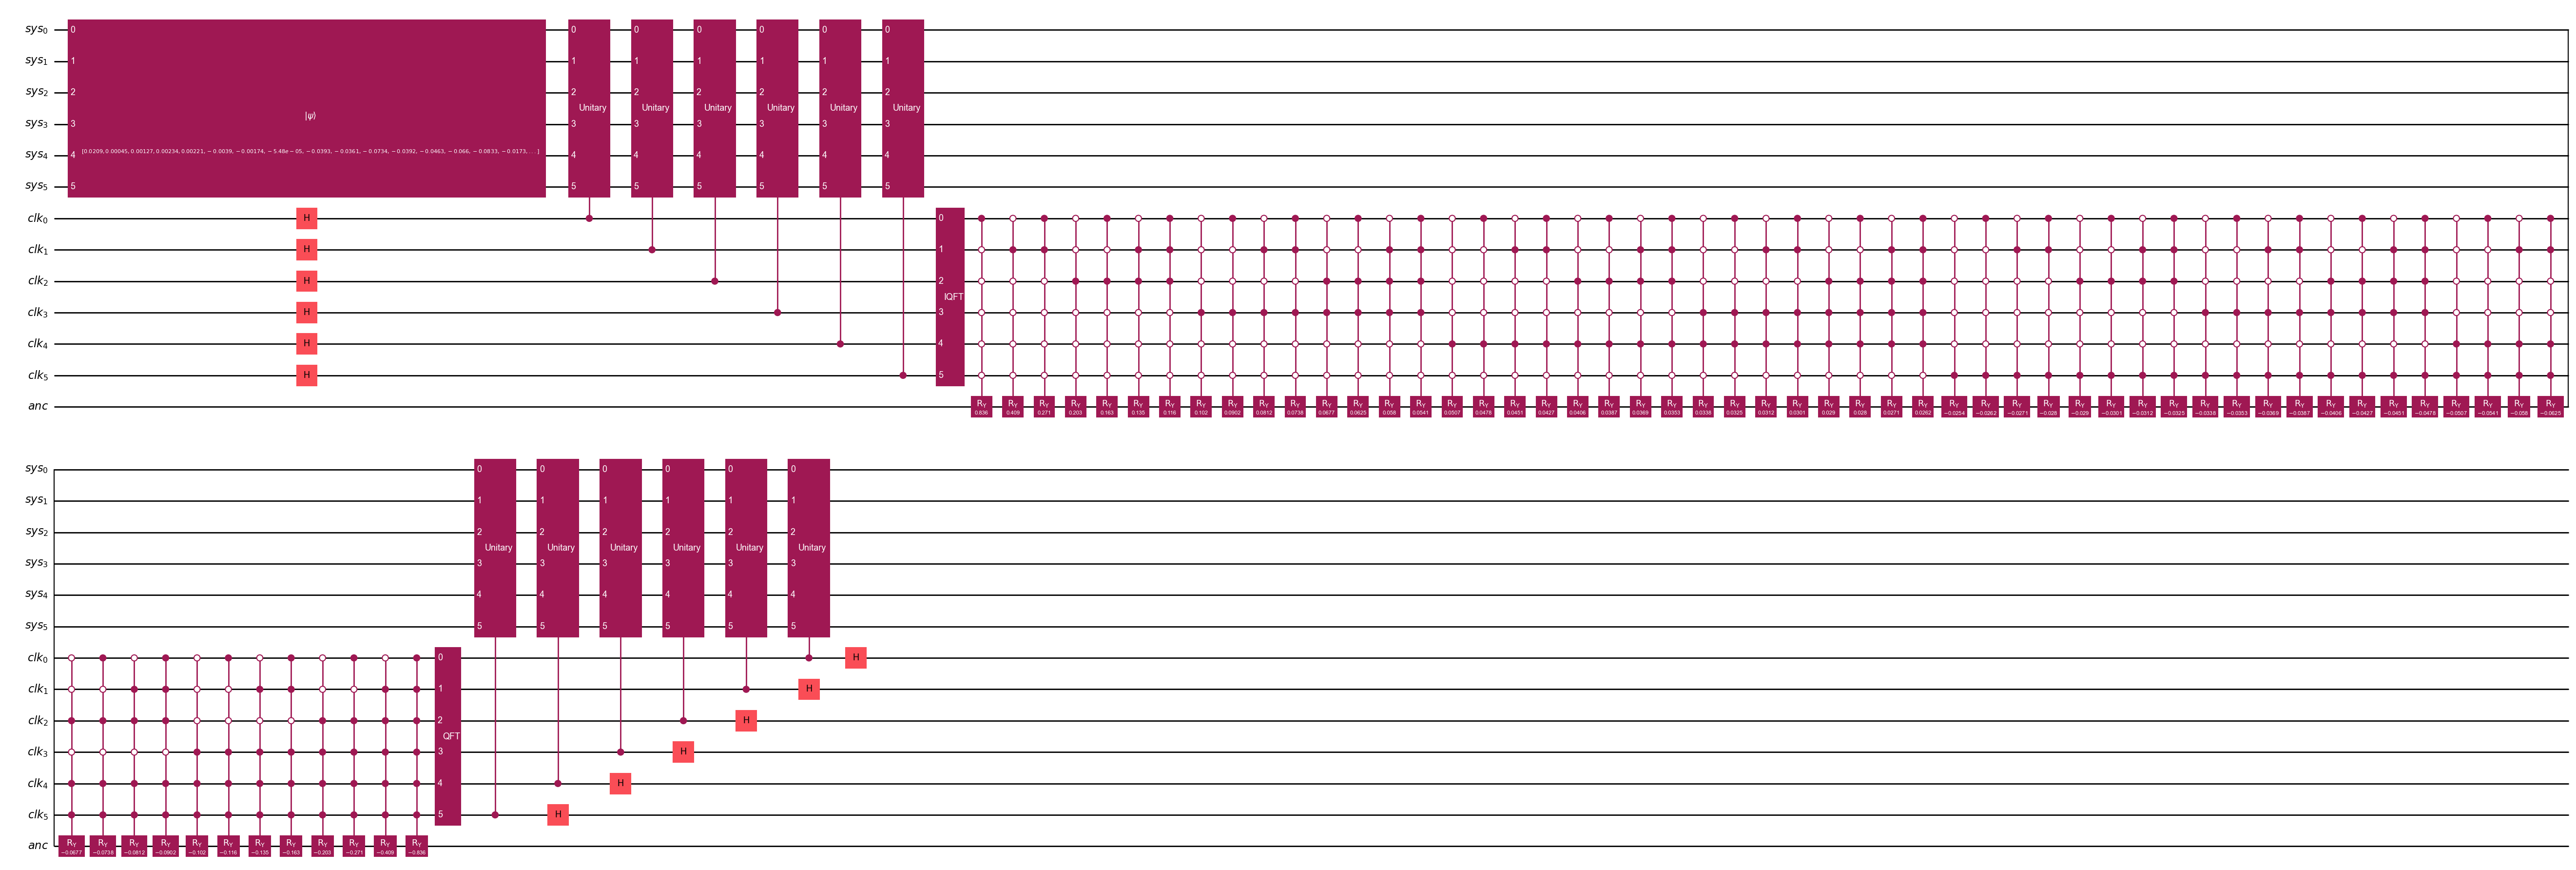

In [127]:
# Visualize the actual full HHL circuit from the final Newton step iteration!
# Note: This plot is massive due to the 64 multi-controlled Ry rotations and large Unitary blocks.
# Double click the output image to expand it in Jupyter.
last_qc.draw('mpl', style='iqp', fold=80)
